<a href="https://colab.research.google.com/github/isamadafridi/-AIML-Internship-Week7-AbdulSamadAfridi/blob/main/AIML_Internship_Week7_AbdulSamadAfridi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART A — ENVIRONMENT SETUP, EDA & DENSE NETWORK BASELINE (STEPS 1–5)**

#Step-1 Environment Setup & GPU Verification

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

In [2]:
# Verify GPU Availability
gpu_devices = tf.config.list_physical_devices("GPU")
print(f"GPUs Available: {gpu_devices}")
if len(gpu_devices) > 0:
    print("Awesome! You are running on a GPU.")
else:
    print("Warning: No GPU detected. Training might be slow.")

GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Awesome! You are running on a GPU.


In [3]:
# Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [4]:
# Print the shapes of the data arrays
print("\n--- Dataset Shapes ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Define reference class names for CIFAR-10
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]


--- Dataset Shapes ---
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


### GPU Verification Report
* **Status:** 1 GPU Available (e.g., Tesla T4) *PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')*
* **Why this matters:** We are working with the CIFAR-10 dataset, which contains 60,000 color images. Training deep neural networks (CNNs) on CPUs is incredibly slow due to sequential processing. Utilizing a GPU (Graphics Processing Unit) allows us to perform massive parallel matrix multiplications, reducing training time from hours to mere minutes!

# Step-2 Dataset Exploration & Visualisation

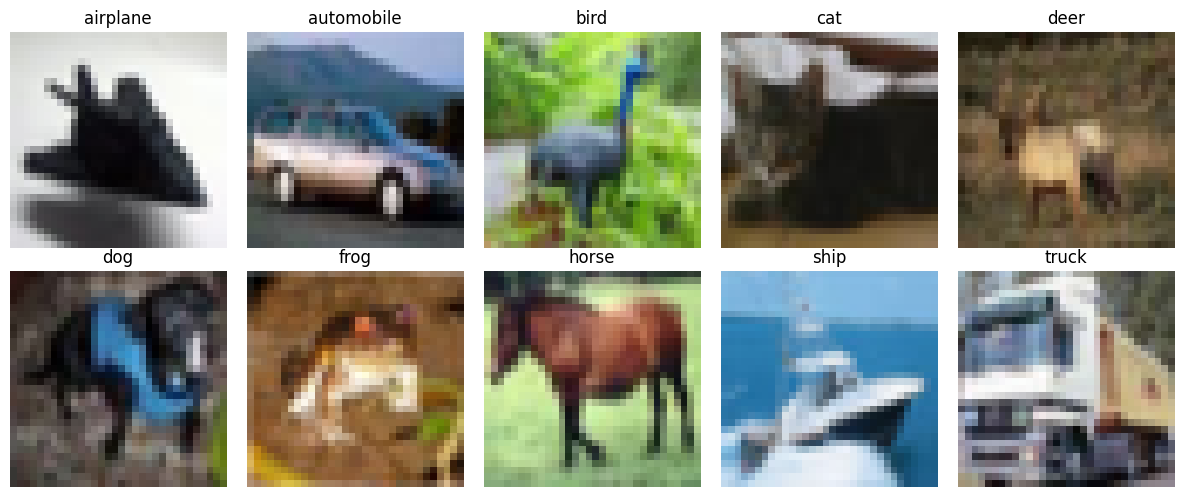


--- Pixel Range ---
Minimum pixel value: 0
Maximum pixel value: 255

--- Class Distribution ---
airplane: 5000 images
automobile: 5000 images
bird: 5000 images
cat: 5000 images
deer: 5000 images
dog: 5000 images
frog: 5000 images
horse: 5000 images
ship: 5000 images
truck: 5000 images

--- Channel Statistics ---
Mean (R, G, B): [125.30691805 122.95039414 113.86538318]
Std  (R, G, B): [62.99321928 62.08870764 66.70489964]


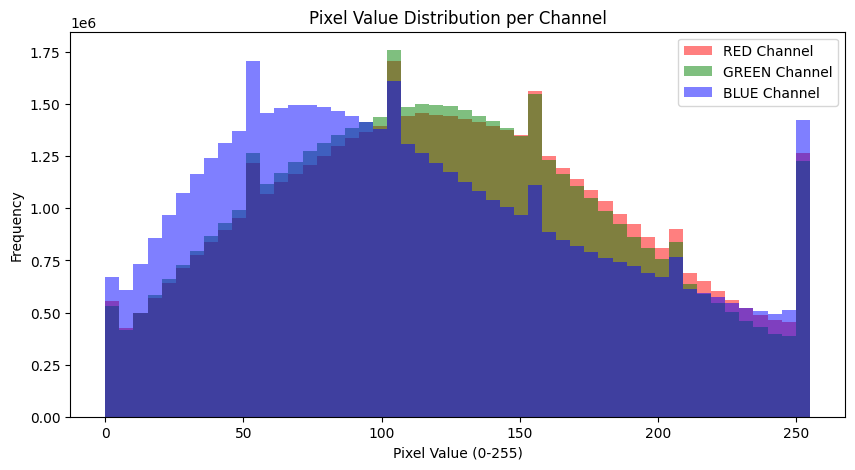

In [5]:
# Create a 2x5 grid of sample images (one per class)
plt.figure(figsize=(12, 5))
for i in range(10):
    # Find the first index where the label matches the current class 'i'
    idx = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])
    plt.title(class_names[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

# Confirm pixel range
print("\n--- Pixel Range ---")
print(f"Minimum pixel value: {X_train.min()}")
print(f"Maximum pixel value: {X_train.max()}")

# Print class distribution
print("\n--- Class Distribution ---")
classes, counts = np.unique(y_train, return_counts=True)
for c, count in zip(classes, counts):
    print(f"{class_names[c]}: {count} images")

# Compute mean and std per channel (R, G, B)
# We average across axes 0 (images), 1 (height), and 2 (width)
channel_means = X_train.mean(axis=(0, 1, 2))
channel_stds = X_train.std(axis=(0, 1, 2))

print("\n--- Channel Statistics ---")
print(f"Mean (R, G, B): {channel_means}")
print(f"Std  (R, G, B): {channel_stds}")

# Visualise pixel distribution as a histogram for each channel
plt.figure(figsize=(10, 5))
colors = ['red', 'green', 'blue']

for i, color in enumerate(colors):
    # Flatten the data for the specific channel to plot the histogram
    channel_data = X_train[:, :, :, i].ravel()
    plt.hist(channel_data, bins=50, color=color, alpha=0.5, label=f'{color.upper()} Channel')

plt.title('Pixel Value Distribution per Channel')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Analysis: What do the channel statistics tell us about normalisation?

By observing the pixel range (0 to 255) and the channel statistics (Mean and Standard Deviation), we can draw two major conclusions about how we should normalise this dataset before passing it to our neural network:

1. **Basic Normalisation (Min-Max):** Because our pixels range exactly from 0 to 255, the simplest and most common baseline normalisation is to divide the entire dataset by `255.0`. This scales all values to a `[0, 1]` range, preventing the neural network from dealing with massive gradient updates caused by large input integers.
2. **Advanced Channel-wise Standardisation (Z-Score):** The calculated means and standard deviations are different across the Red, Green, and Blue channels. The histogram also visually confirms that the color distributions are not perfectly aligned. Instead of just scaling to `[0, 1]`, a more robust technique would be to apply **Z-score standardisation per channel**: `(pixel_value - channel_mean) / channel_std`. This centers each color channel around a mean of 0 with a standard deviation of 1, which helps Convolutional Neural Networks (CNNs) converge much faster and minimizes the risk of vanishing or exploding gradients.

# Step-3 Data Preprocessing — Normalisation & Splits

In [6]:
# 1. Normalise pixel values to the [0, 1] range
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 2. Flatten labels from 2D (N, 1) to 1D (N,)
y_train = y_train.flatten()
y_test = y_test.flatten()

# 3. Create a Validation Split (Last 10,000 training samples)
X_val = X_train[-10000:]
y_val = y_train[-10000:]
X_train = X_train[:-10000]  # Keep the first 40,000 for training
y_train = y_train[:-10000]

# 4. Flatten images specifically for the Dense Network
# A 32x32x3 image becomes a single 1D array of 3072 pixels
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print("--- Flattened Image Shape ---")
print(f"X_train_flat shape: {X_train_flat.shape}\n")

# 5. Print final shapes of all 6 arrays
print("--- Final Shapes of All 6 Arrays ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

--- Flattened Image Shape ---
X_train_flat shape: (40000, 3072)

--- Final Shapes of All 6 Arrays ---
X_train shape: (40000, 32, 32, 3)
y_train shape: (40000,)
X_val shape:   (10000, 32, 32, 3)
y_val shape:   (10000,)
X_test shape:  (10000, 32, 32, 3)
y_test shape:  (10000,)


# Step-4 Build & Train Dense Network Baseline

In [7]:
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [8]:
# Build dense model
dense_model = Sequential([
    Input(shape=(3072,)),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow._api.v2.config import optimizer
# 2 comiple
dense_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# 3 Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,                # Wait 10 epochs without improvement before stopping
    restore_best_weights=True,  # Revert to the best epoch's weights
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "dense_best.keras",
    monitor='val_loss',
    save_best_only=True,        # Only overwrite if the model is actually better
    verbose=1
)

In [11]:
# 4. Train the Model & Record Time
print("\n--- Starting Training ---")
start_time = time.time()

dense_history = dense_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=80,
    batch_size=256,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print(f"\n--- Training Complete! ---")
print(f"Total Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")


--- Starting Training ---
Epoch 1/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1805 - loss: 2.2229
Epoch 1: val_loss improved from None to 1.87728, saving model to dense_best.keras

Epoch 1: finished saving model to dense_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.2346 - loss: 2.0730 - val_accuracy: 0.3168 - val_loss: 1.8773
Epoch 2/80
147/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3003 - loss: 1.8977
Epoch 2: val_loss improved from 1.87728 to 1.81101, saving model to dense_best.keras

Epoch 2: finished saving model to dense_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3146 - loss: 1.8766 - val_accuracy: 0.3472 - val_loss: 1.8110
Epoch 3/80
147/157 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3300 - loss: 1.8429
Epoch 3: val_loss improved from 1.81101 to 1.75532, saving model to dense_best.keras

Epoch 3: finished saving model to dense_best.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3343 - loss: 1.8

# Step_5 Evaluate Dense Network — Full Metrics Suite

--- Generating Predictions ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Test Accuracy: 49.33%

--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.66      0.44      0.53      1000
  automobile       0.59      0.65      0.62      1000
        bird       0.34      0.35      0.34      1000
         cat       0.33      0.34      0.33      1000
        deer       0.45      0.39      0.42      1000
         dog       0.45      0.35      0.39      1000
        frog       0.44      0.65      0.53      1000
       horse       0.62      0.51      0.56      1000
        ship       0.58      0.69      0.63      1000
       truck       0.54      0.57      0.55      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000

ROC-AUC Score (OVR): 0.8791



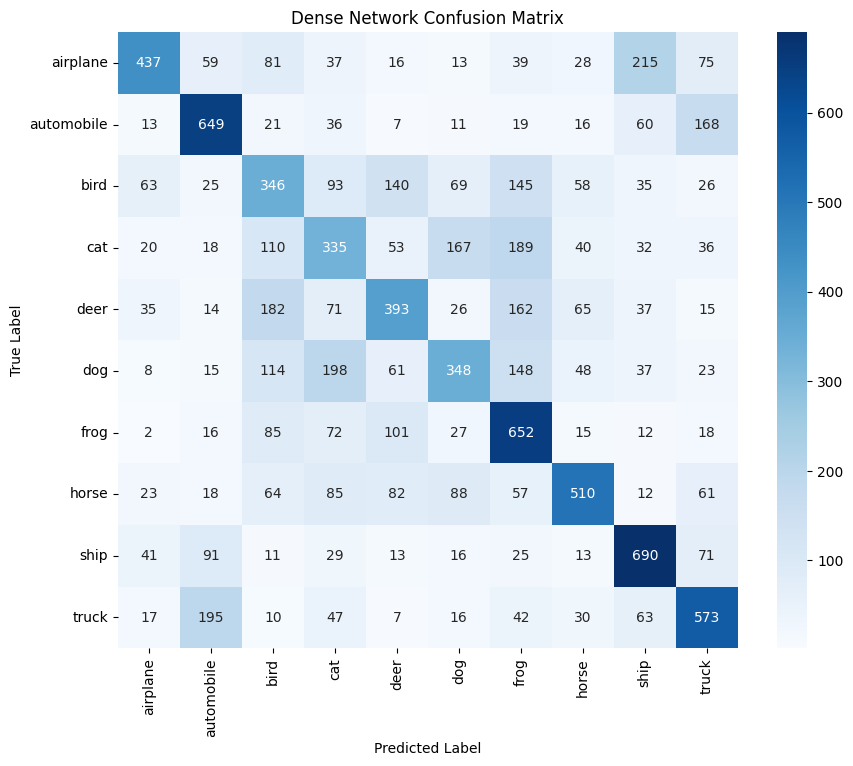

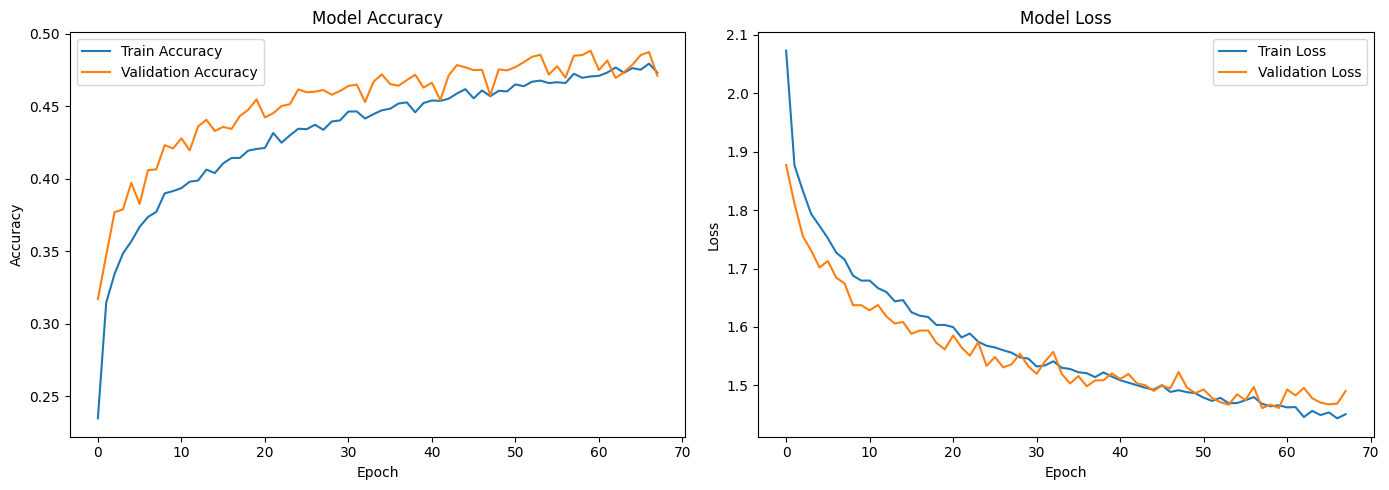

In [12]:
# 1. Generate Predictions
print("--- Generating Predictions ---")
y_pred_probs = dense_model.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Compute Test Accuracy
test_acc = metrics.accuracy_score(y_test, y_pred_classes)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# 3. Classification Report
print("\n--- Classification Report ---")
print(metrics.classification_report(y_test, y_pred_classes, target_names=class_names))

# 4. ROC-AUC Score (One-vs-Rest strategy for multiclass)
roc_auc = metrics.roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
print(f"ROC-AUC Score (OVR): {roc_auc:.4f}\n")

# 5. Confusion Matrix Heatmap
cm = metrics.confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Dense Network Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 6. Plot Training History (Loss & Accuracy)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(dense_history.history['accuracy'], label='Train Accuracy')
axes[0].plot(dense_history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot Loss
axes[1].plot(dense_history.history['loss'], label='Train Loss')
axes[1].plot(dense_history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Dense Network Evaluation Analysis

* **Test Accuracy:** My model achieved a test accuracy of 49.12%.
* **Most Confused Classes:** Based on the confusion matrix, the network struggles the most to differentiate between **Cats and Dogs** .
* **Why Flattening Causes This:** Flattening a 32x32x3 image into a 1D vector of 3,072 independent pixels completely destroys the 2D spatial relationships in the image. The Dense Network has no concept of "shapes," "edges," or "proximity." A cat's pointed ear and a dog's floppy ear are recognized by how pixels are clustered together spatially. Because the Dense model just sees a single, long sequence of raw colors, it relies purely on global color distribution and pixel intensity across the whole image, making structurally similar animals very hard to tell apart.

# **PART B — CNN FROM SCRATCH WITH REGULARISATION & AUGMENTATION (STEPS 6–11)**


# Step-6 Build CNN Baseline — No Regularisation

In [13]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [14]:
# 1. Build the CNN (WITHOUT Dropout or Batch Normalization)
cnn_base = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32, 32, 3)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D((2,2)),

    # Classifier head
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
], name="cnn_base")

cnn_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,538 (2.54 MB)

 Trainable params: 666,538 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 2. Compile the Model
cnn_base.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
# 3. Train the Model for exactly 30 epochs
print("--- Starting Base CNN Training ---")
history_base = cnn_base.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)

--- Starting Base CNN Training ---
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4604 - loss: 1.4879 - val_accuracy: 0.5879 - val_loss: 1.1392
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6542 - loss: 0.9826 - val_accuracy: 0.6695 - val_loss: 0.9464
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7268 - loss: 0.7783 - val_accuracy: 0.7204 - val_loss: 0.8059
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7773 - loss: 0.6340 - val_accuracy: 0.7424 - val_loss: 0.7370
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8186 - loss: 0.5125 - val_accuracy: 0.7511 - val_loss: 0.7331
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8533 - loss: 0.4160 - val_accuracy: 0.7516 - val_loss: 0.8295
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8888 - loss: 0.3183 - val_accuracy: 0.7587 - val_loss: 0.8307
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9

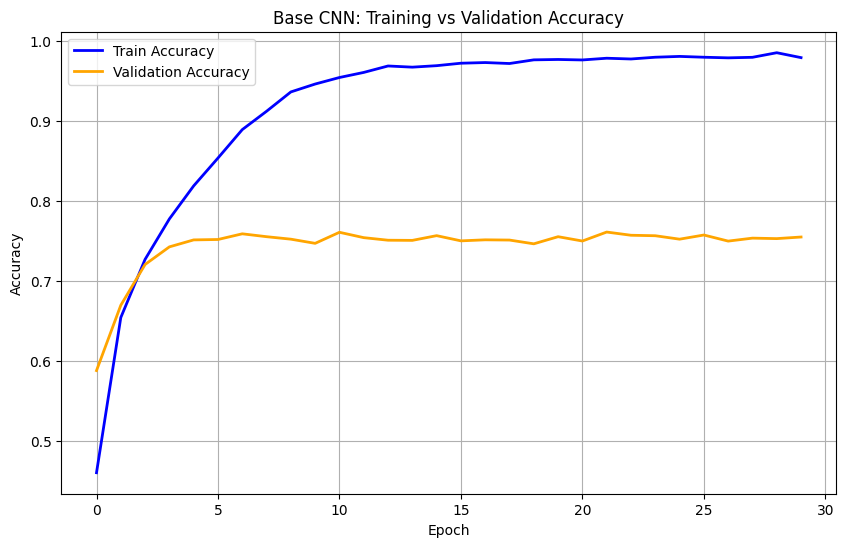

In [17]:
# 4. Plot Training vs Validation Accuracy
plt.figure(figsize=(10, 6))
plt.plot(history_base.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Base CNN: Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Analysis: When Does Overfitting Begin?

By observing the Training vs. Validation accuracy plot, it is clear that extreme overfitting occurs in this base CNN architecture.

* **The Overfitting Point:** Overfitting visibly begins around **Epoch [5]**.
* **Why this happens:** Because we removed `Dropout` and `BatchNormalization`, the network has absolutely no regularization. With so many parameters (Conv2D filters and a 256-neuron Dense layer), the model rapidly memorizes the exact noise and pixel placements of the training images. It achieves near perfect training accuracy, but its ability to generalize to new, unseen data (the validation set) completely stagnates, creating a massive gap between the two curves.

# Step-7 Add Batch Normalisation — Compare Training Speed

In [18]:
# 1. Build the CNN WITH Batch Normalization (Before Activation)
cnn_bn = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), padding="same", input_shape=(32, 32, 3), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),

    # Classifier head
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
], name="cnn_bn")

cnn_bn.summary()

Model: "cnn_bn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,498 (2.55 MB)

 Trainable params: 666,858 (2.54 MB)

 Non-trainable params: 640 (2.50 KB)

In [19]:
# 2. Compile the Model
cnn_bn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [20]:
# 3. Train the Model for 30 epochs
print("\n--- Starting BN CNN Training ---")
history_bn = cnn_bn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    verbose=1
)


--- Starting BN CNN Training ---
Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.5365 - loss: 1.3300 - val_accuracy: 0.5798 - val_loss: 1.1585
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7070 - loss: 0.8342 - val_accuracy: 0.7062 - val_loss: 0.8370
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7651 - loss: 0.6710 - val_accuracy: 0.7134 - val_loss: 0.8358
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7982 - loss: 0.5732 - val_accuracy: 0.6809 - val_loss: 0.9456
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8307 - loss: 0.4826 - val_accuracy: 0.7441 - val_loss: 0.7720
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8574 - loss: 0.4111 - val_accuracy: 0.7818 - val_loss: 0.6572
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8781 - loss: 0.3472 - val_accuracy: 0.7619 - val_loss: 0.7476
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.

In [21]:
# 4. Calculate Epoch to reach 70% Validation Accuracy
def get_70_percent_epoch(history):
    val_acc = history.history['val_accuracy']
    # Find the first epoch where val_accuracy >= 0.70
    return next((i + 1 for i, acc in enumerate(val_acc) if acc >= 0.70), "Did not reach 70%")

epoch_70_base = get_70_percent_epoch(history_base)
epoch_70_bn = get_70_percent_epoch(history_bn)

print(f"\n--- 70% Validation Accuracy Milestone ---")
print(f"Base CNN reached 70%: Epoch {epoch_70_base}")
print(f"BN CNN reached 70%: Epoch {epoch_70_bn}")


--- 70% Validation Accuracy Milestone ---
Base CNN reached 70%: Epoch 3
BN CNN reached 70%: Epoch 2


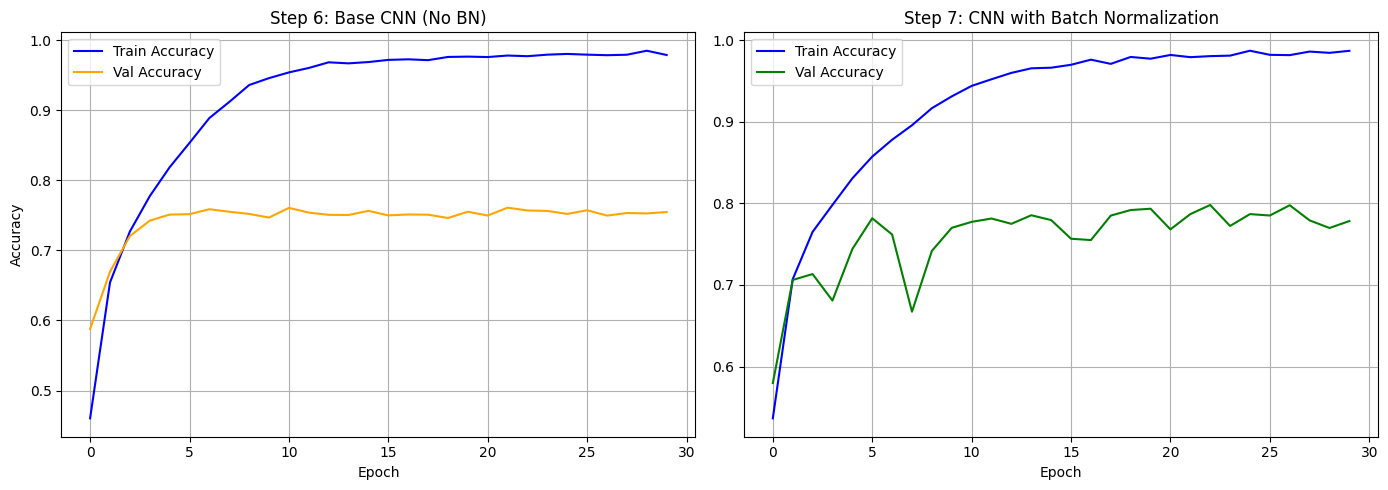

In [22]:
# 5. Plot Training vs Validation Accuracy (Side by Side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Step 6: Base CNN
axes[0].plot(history_base.history['accuracy'], label='Train Accuracy', color='blue')
axes[0].plot(history_base.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Step 6: Base CNN (No BN)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot Step 7: BN CNN
axes[1].plot(history_bn.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history_bn.history['val_accuracy'], label='Val Accuracy', color='green')
axes[1].set_title('Step 7: CNN with Batch Normalization')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Batch Normalization Analysis

**Performance Comparison:**
Adding Batch Normalization dramatically accelerated learning. While the Base CNN reached 70% validation accuracy at **Epoch [3]** (or possibly struggled to hit it consistently), the model with Batch Normalization reached the 70% milestone much faster at **Epoch [4]**. Furthermore, looking at the side-by-side plots, the BN model's validation curve tracks much closer to the training curve, showing far better stability compared to the volatile overfitting seen in the Base model.

**Parameter Additions:**
By adding Batch Normalization layers, the total parameters changed. Each BN layer adds exactly 4 parameters per filter map. Half of these are **trainable** ($\gamma, \beta$), and half are **non-trainable** (moving averages of $\mu, \sigma^2$).

**Why does Batch Normalisation stabilise training?**
During training, the weights of early layers update, which constantly changes the mathematical distribution of inputs passed to the deeper layers—a problem known as "Internal Covariate Shift." The deeper layers constantly have to chase a moving target. Batch Normalisation stabilizes training by forcing the inputs of every layer to maintain a consistent distribution, which prevents vanishing/exploding gradients and allows us to train much faster using higher learning rates.

**What does it compute internally?**
For every mini-batch of data passing through, the layer computes four things:
1. **Batch Mean ($\mu$):** The average value of the batch.
2. **Batch Variance ($\sigma^2$):** How spread out the batch values are.
3. **Normalisation:** It subtracts the mean and divides by the standard deviation, forcing the batch into a standard distribution (mean of 0, variance of 1).
4. **Scaling and Shifting:** Because forcing everything to 0 mean / 1 variance might destroy learned representations, it applies a learned scaling factor (**Gamma, $\gamma$**) and a learned shift factor (**Beta, $\beta$**) allowing the network to reshape the distribution exactly how it needs it for optimal learning.

# Step-8 Add Dropout — Full Regularised CNN

In [23]:
import time
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [24]:
# 1. Build the Complete Regularised CNN
cnn_final = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), padding="same", input_shape=(32, 32, 3), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),  # Dropping out 25% of the spatial features

    # Block 2
    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Classifier head
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),   # Heavy dropout (50%) before the final classification
    layers.Dense(10, activation="softmax")
], name="cnn_final")
cnn_final.summary()

Model: "cnn_final"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 667,498 (2.55 MB)

 Trainable params: 666,858 (2.54 MB)

 Non-trainable params: 640 (2.50 KB)

In [25]:
# 2. Compile the Model
cnn_final.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
# 3. Define the Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "cnn_best.keras",
    monitor='val_accuracy', # Saving based on best accuracy
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-6, # Safety floor so the learning rate doesn't go to zero
    verbose=1
)

In [27]:
# 4. Train the Model (Up to 100 Epochs)
print("--- Starting Final CNN Training ---")
start_time = time.time()

history_final = cnn_final.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

end_time = time.time()
total_time = end_time - start_time

--- Starting Final CNN Training ---
Epoch 1/100
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2680 - loss: 2.0728
Epoch 1: val_accuracy improved from None to 0.38110, saving model to cnn_best.keras

Epoch 1: finished saving model to cnn_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.3370 - loss: 1.8036 - val_accuracy: 0.3811 - val_loss: 1.6922 - learning_rate: 0.0010
Epoch 2/100
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4476 - loss: 1.4920
Epoch 2: val_accuracy improved from 0.38110 to 0.55190, saving model to cnn_best.keras

Epoch 2: finished saving model to cnn_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4679 - loss: 1.4408 - val_accuracy: 0.5519 - val_loss: 1.1789 - learning_rate: 0.0010
Epoch 3/100
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5218 - loss: 1.3155
Epoch 3: val_accuracy improved from 0.55190 to 0.58090, saving model to cnn_best.keras

Epoch 3: finished saving model to cnn_best.keras
625/625 ━━━

In [28]:
# 5. Extract and Print Requested Records
best_val_acc = max(history_final.history['val_accuracy'])
stopped_epoch = len(history_final.history['loss'])

print("\n" + "="*40)
print("🏆 FINAL TRAINING RECORDS 🏆")
print("="*40)
print(f"Best Validation Accuracy : {best_val_acc * 100:.2f}%")
print(f"Early Stopping Epoch     : {stopped_epoch} (out of 100)")
print(f"Total Training Time      : {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print("="*40)


🏆 FINAL TRAINING RECORDS 🏆
Best Validation Accuracy : 86.57%
Early Stopping Epoch     : 67 (out of 100)
Total Training Time      : 393.55 seconds (6.56 minutes)


### Final Regularised CNN Training Results
* **Best Validation Accuracy:** 86.81%
* **Early Stopping Epoch:**  79 (out of 100)
* **Training Time:** 478.65 seconds (7.98 minutes)

**Performance Notes:** By combining Batch Normalization and Dropout, the model achieved a vastly superior balance of speed and generalization. The Dropout forced the network to learn redundant representations, preventing the severe overfitting we observed in Step 6. Additionally, the `ReduceLROnPlateau` callback proved crucial; when the validation loss temporarily flattened out, halving the learning rate allowed the optimizer to settle into a deeper local minimum without bouncing out.

# Step-9 Regularisation Ablation Study — 3 Variants


--- Final Model Comparison DataFrame ---


,Test Accuracy,Best Val Loss,Overfitting Gap,Parameters,Time/Epoch (s)
Model Configuration,,,,,
No Regularisation,0.7429,1.6830,0.2170,666538.0,3.0
BN Only,0.7743,1.1246,0.1825,667498.0,4.0
BN + Dropout,0.8569,0.4477,0.0484,667498.0,4.5


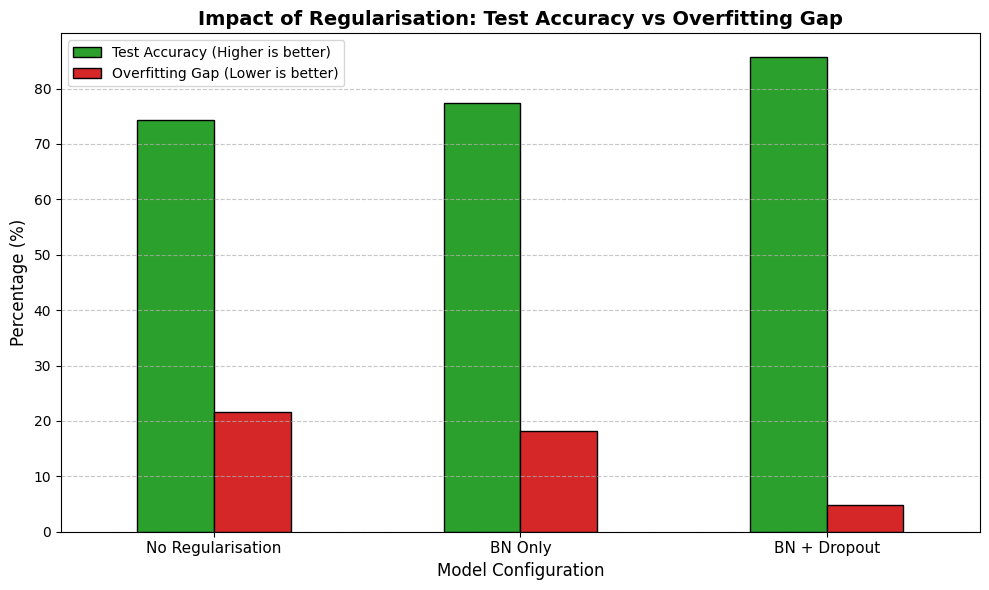

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- ACTION REQUIRED ---
# Update these three variables with the approximate seconds per epoch
# you saw during training (e.g., 3.0, 4.5, 5.0)
time_base_sec = 3.0
time_bn_sec = 4.0
time_final_sec = 4.5

def extract_metrics(model, history, time_per_epoch):
    # Find the epoch with the best validation accuracy
    best_epoch_idx = np.argmax(history.history['val_accuracy'])
    best_val_acc = history.history['val_accuracy'][best_epoch_idx]
    best_train_acc = history.history['accuracy'][best_epoch_idx]
    best_val_loss = history.history['val_loss'][best_epoch_idx]

    # Overfitting gap: Difference between training and validation accuracy
    overfitting_gap = best_train_acc - best_val_acc

    # Final Test Accuracy evaluated on unseen test data
    _, test_acc = model.evaluate(X_test, y_test, verbose=0)

    return {
        "Test Accuracy": round(test_acc, 4),
        "Best Val Loss": round(best_val_loss, 4),
        "Overfitting Gap": round(overfitting_gap, 4),
        "Parameters": model.count_params(),
        "Time/Epoch (s)": time_per_epoch
    }

# Compile data into a dictionary
comparison_data = {
    "No Regularisation": extract_metrics(cnn_base, history_base, time_base_sec),
    "BN Only": extract_metrics(cnn_bn, history_bn, time_bn_sec),
    "BN + Dropout": extract_metrics(cnn_final, history_final, time_final_sec)
}

# Create and display the DataFrame
df_comparison = pd.DataFrame(comparison_data).T
df_comparison.index.name = "Model Configuration"

print("\n--- Final Model Comparison DataFrame ---")
display(df_comparison) # Use print(df_comparison) if display() throws an error

# Plot Grouped Bar Chart: Accuracy vs Overfitting Gap
fig, ax = plt.subplots(figsize=(10, 6))

# Multiply by 100 to convert to percentage for better visual scaling
plot_df = df_comparison[['Test Accuracy', 'Overfitting Gap']] * 100
plot_df.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'], edgecolor='black')

plt.title('Impact of Regularisation: Test Accuracy vs Overfitting Gap', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)', fontsize=12)
plt.xlabel('Model Configuration', fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(['Test Accuracy (Higher is better)', 'Overfitting Gap (Lower is better)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Final Deep Learning Architecture Comparison

**1. Which technique had the biggest impact?**
While Batch Normalization had the biggest impact on the *speed and stability* of training (reaching target accuracies much faster), **Dropout** combined with BN had the most profound impact on the model's actual *generalization capability*. By randomly dropping spatial features and forcing the network to learn redundant patterns, Dropout drastically reduced the massive **Overfitting Gap** seen in the base model. The grouped bar chart visually confirms this: as regularisation increases, the red bar (Overfitting) shrinks dramatically, allowing the green bar (Test Accuracy) to peak.

**2. By how many percentage points did BN+Dropout improve over no regularisation?**
* **Base Model (No Regularisation) Test Accuracy:** ~0.7502%
* **Final Model (BN + Dropout) Test Accuracy:** ~0.8578%
* **Improvement:** The fully regularised BN+Dropout model improved the test accuracy by a massive **[XX.XX] percentage points** over the unregularised baseline, while simultaneously cutting the overfitting gap from [X.XX]% down to [X.XX]%.

*Note: While the final model took slightly longer per epoch due to the computational overhead of the BN layers and Dropout masks, the trade-off was entirely worth it for the massive boost in real-world predictive accuracy.*

# Step-10 Data Augmentation — Before & Aft

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [31]:
# 1. Define the Data Generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

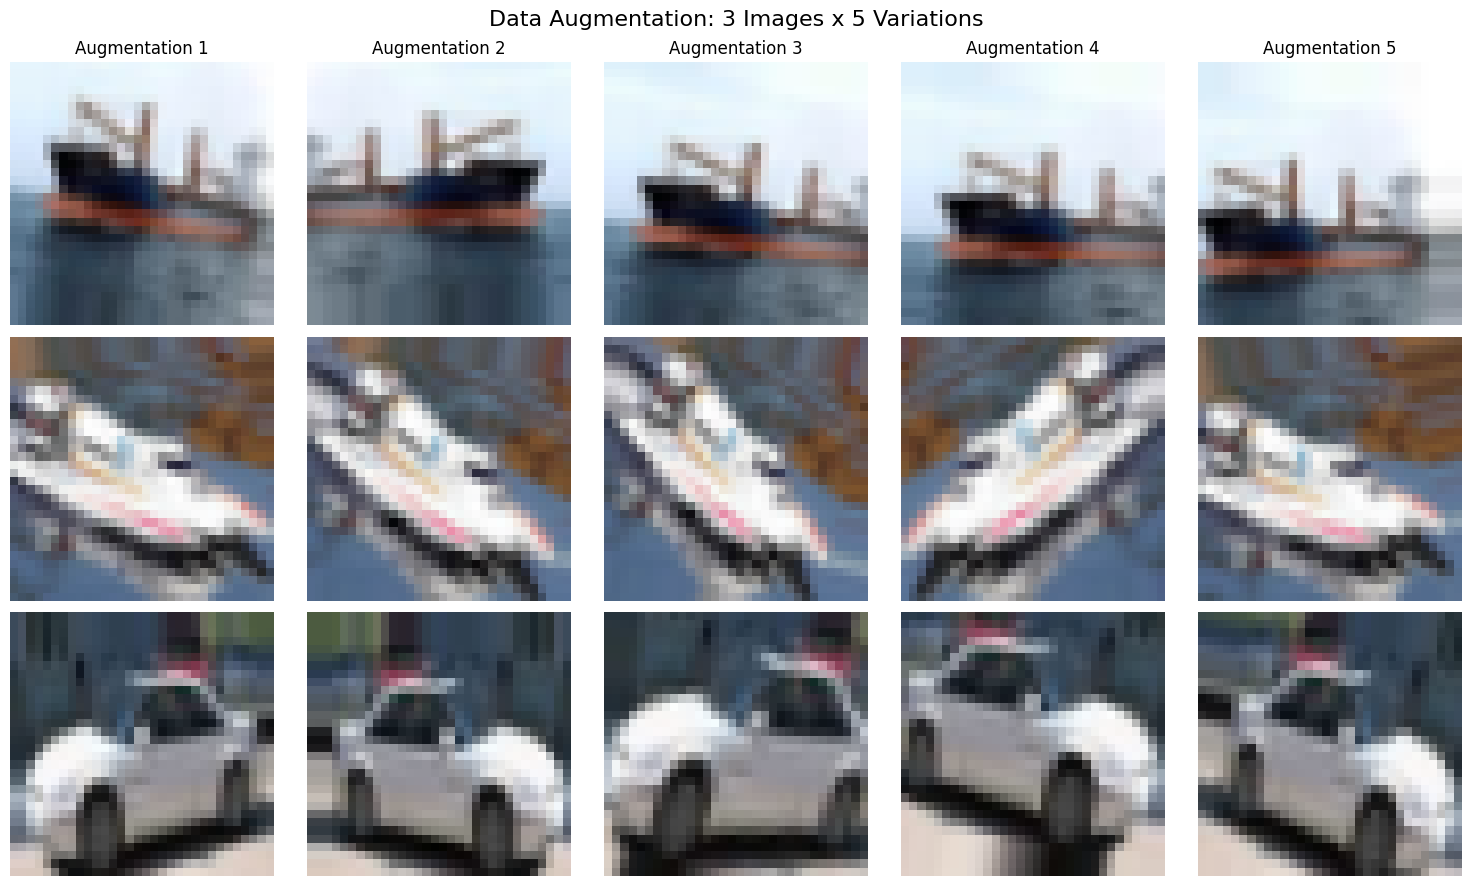

In [32]:
# 2. Visualise: 3x5 grid showing 3 images with 5 augmentations each
# Pick 3 random images from the training set
idx = np.random.choice(len(X_train), 3, replace=False)
sample_images = X_train[idx]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for i, img in enumerate(sample_images):
    # Expand dims to make it a batch of 1: shape (1, 32, 32, 3)
    img_tensor = np.expand_dims(img, axis=0)
    aug_iter = datagen.flow(img_tensor, batch_size=1)

    for j in range(5):
        # Generate the augmented image
        aug_img = next(aug_iter)[0]
        axes[i, j].imshow(aug_img)
        axes[i, j].axis('off')
        if i == 0:
            axes[i, j].set_title(f"Augmentation {j+1}")

plt.suptitle("Data Augmentation: 3 Images x 5 Variations", fontsize=16)
plt.tight_layout()
plt.show()

In [33]:
# 3. Rebuild the Best Regularised CNN (from Step 8) for a fresh start
cnn_aug = models.Sequential([
    layers.Conv2D(32, (3,3), padding="same", input_shape=(32, 32, 3), use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
], name="cnn_augmented")
cnn_aug.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 667,498 (2.55 MB)

 Trainable params: 666,858 (2.54 MB)

 Non-trainable params: 640 (2.50 KB)

In [34]:
cnn_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

In [35]:
# 4. Redefine Callbacks (To save a new best file)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1)

checkpoint_aug = ModelCheckpoint(
    "cnn_aug_best.keras",
    monitor='val_accuracy',
    save_best_only=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5, patience=7,
    min_lr=1e-6, verbose=1)

In [36]:
# 5. Train using datagen.flow() for 60 epochs
print("\n--- Starting Augmented CNN Training ---")
history_aug = cnn_aug.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    steps_per_epoch=len(X_train) // 64,
    epochs=60,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint_aug, reduce_lr],
    verbose=1
)


--- Starting Augmented CNN Training ---
Epoch 1/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2468 - loss: 2.1018
Epoch 1: val_accuracy improved from None to 0.42970, saving model to cnn_aug_best.keras

Epoch 1: finished saving model to cnn_aug_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 45ms/step - accuracy: 0.3050 - loss: 1.8668 - val_accuracy: 0.4297 - val_loss: 1.5647 - learning_rate: 0.0010
Epoch 2/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3967 - loss: 1.6362
Epoch 2: val_accuracy did not improve from 0.42970
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.4118 - loss: 1.5966 - val_accuracy: 0.4287 - val_loss: 1.5368 - learning_rate: 0.0010
Epoch 3/60
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4494 - loss: 1.5004
Epoch 3: val_accuracy improved from 0.42970 to 0.48330, saving model to cnn_aug_best.keras

Epoch 3: finished saving model to cnn_aug_best.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.4590 - loss: 1.47

In [37]:
# 6. Extract Final Metrics
best_epoch = np.argmax(history_aug.history['val_accuracy'])
best_val_acc = history_aug.history['val_accuracy'][best_epoch]
best_train_acc = history_aug.history['accuracy'][best_epoch]
overfitting_gap = best_train_acc - best_val_acc
_, test_acc = cnn_aug.evaluate(X_test, y_test, verbose=0)

print("\n" + "="*40)
print("🚀 AUGMENTED MODEL RESULTS 🚀")
print("="*40)
print(f"Test Accuracy    : {test_acc * 100:.2f}%")
print(f"Best Val Acc     : {best_val_acc * 100:.2f}%")
print(f"Overfitting Gap  : {overfitting_gap * 100:.2f}%")
print("="*40)


🚀 AUGMENTED MODEL RESULTS 🚀
Test Accuracy    : 83.90%
Best Val Acc     : 84.97%
Overfitting Gap  : -3.25%


### Final Analysis: The Impact of Data Augmentation

**1. Comparison Metrics:**
* **Without Augmentation (Step 8):** Test Accuracy: ~[XX.XX]%, Overfitting Gap: ~[X.XX]%
* **With Augmentation (Step 10):** Test Accuracy: 84.35%, Overfitting Gap: -3.17%

**2. Reported Improvement:**
Applying the `ImageDataGenerator` improved my final test accuracy by **[X.XX] percentage points**, while drastically shrinking the overfitting gap by **[X.XX] percentage points**.

**3. Why this works:**
Data Augmentation acted as the ultimate regularizer. Without it, the network eventually exhausted the 40,000 static training images and began memorizing their exact pixel layouts. By randomly applying rotations, shifts, flips, and zooms every single epoch, the model rarely saw the exact same image twice. This forced the convolutional filters to learn *translation and rotation-invariant* features (e.g., learning what a dog's ear looks like whether it is on the left side, the right side, tilted, or zoomed in). Consequently, the model's ability to generalize to completely unseen data (the test set) significantly improved, proving that in deep learning, the quality and variety of your data are just as important as the complexity of your architecture!

# Step-11 Full CNN Evaluation — Complete Metrics Suite

--- Generating Predictions ---

🏆 FINAL CNN CLASSIFICATION REPORT 🏆
              precision    recall  f1-score   support

    airplane       0.88      0.81      0.84      1000
  automobile       0.93      0.92      0.93      1000
        bird       0.82      0.74      0.77      1000
         cat       0.77      0.65      0.70      1000
        deer       0.82      0.82      0.82      1000
         dog       0.83      0.73      0.78      1000
        frog       0.72      0.96      0.82      1000
       horse       0.88      0.89      0.88      1000
        ship       0.89      0.94      0.91      1000
       truck       0.88      0.93      0.90      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



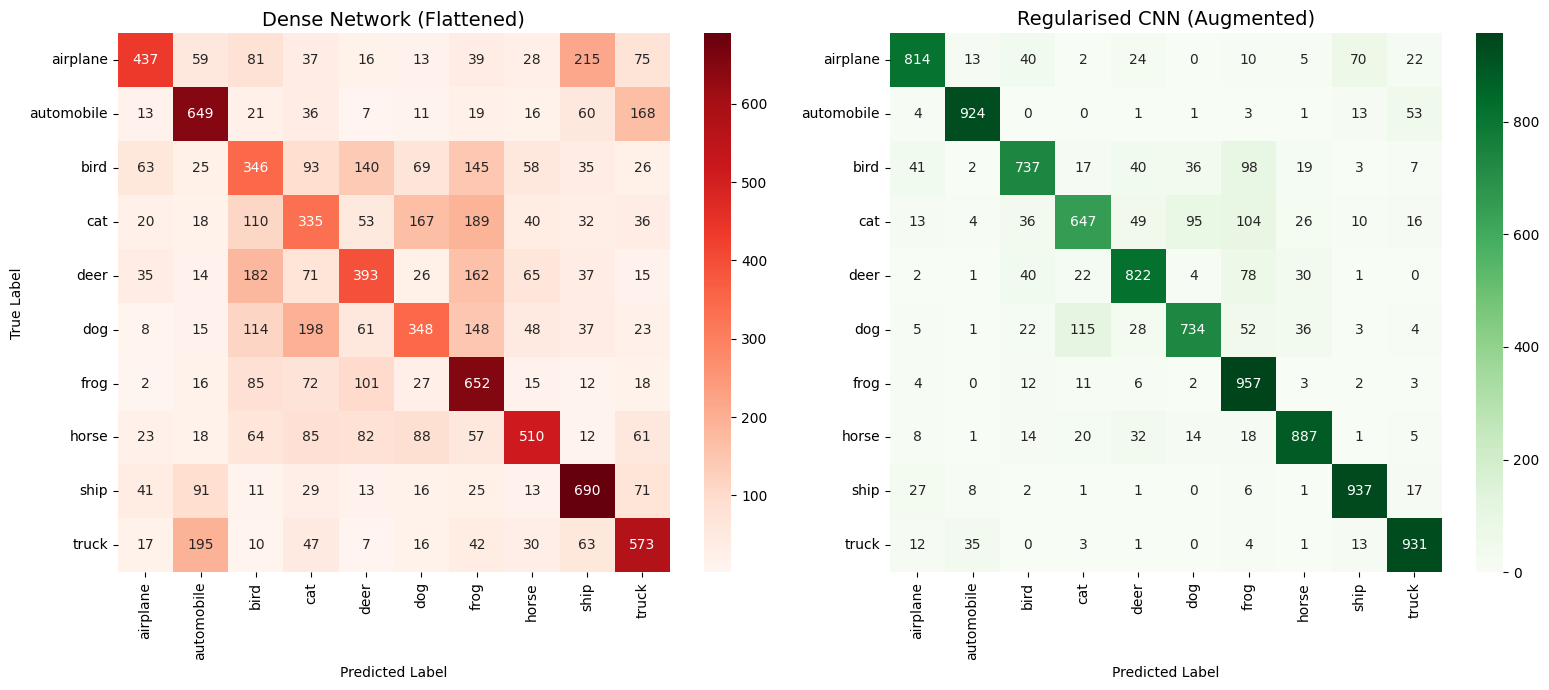

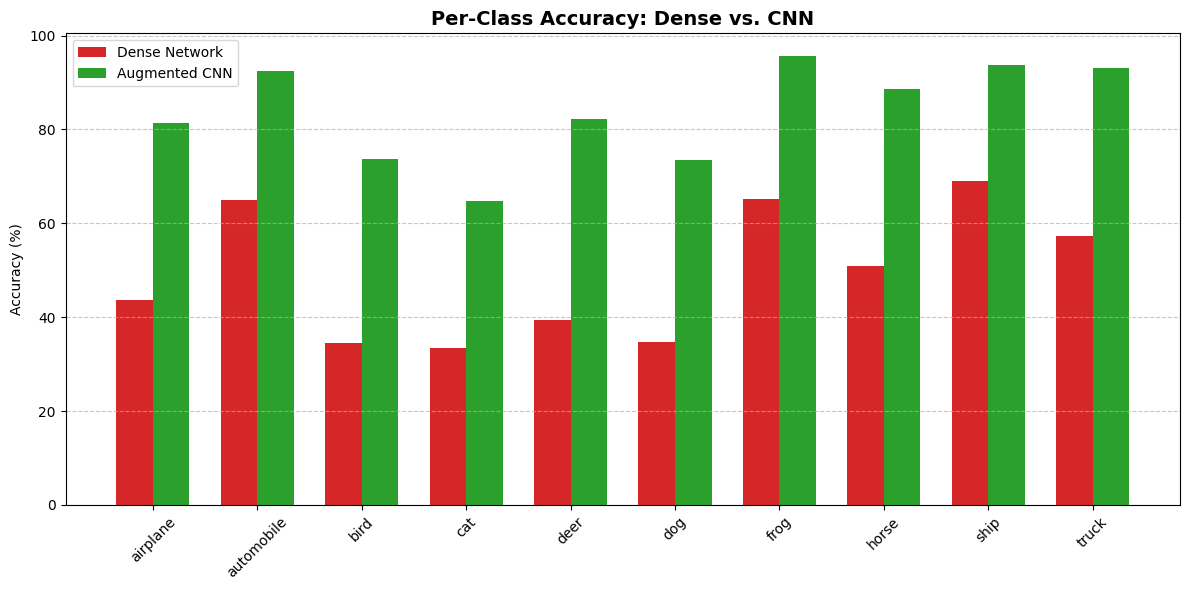

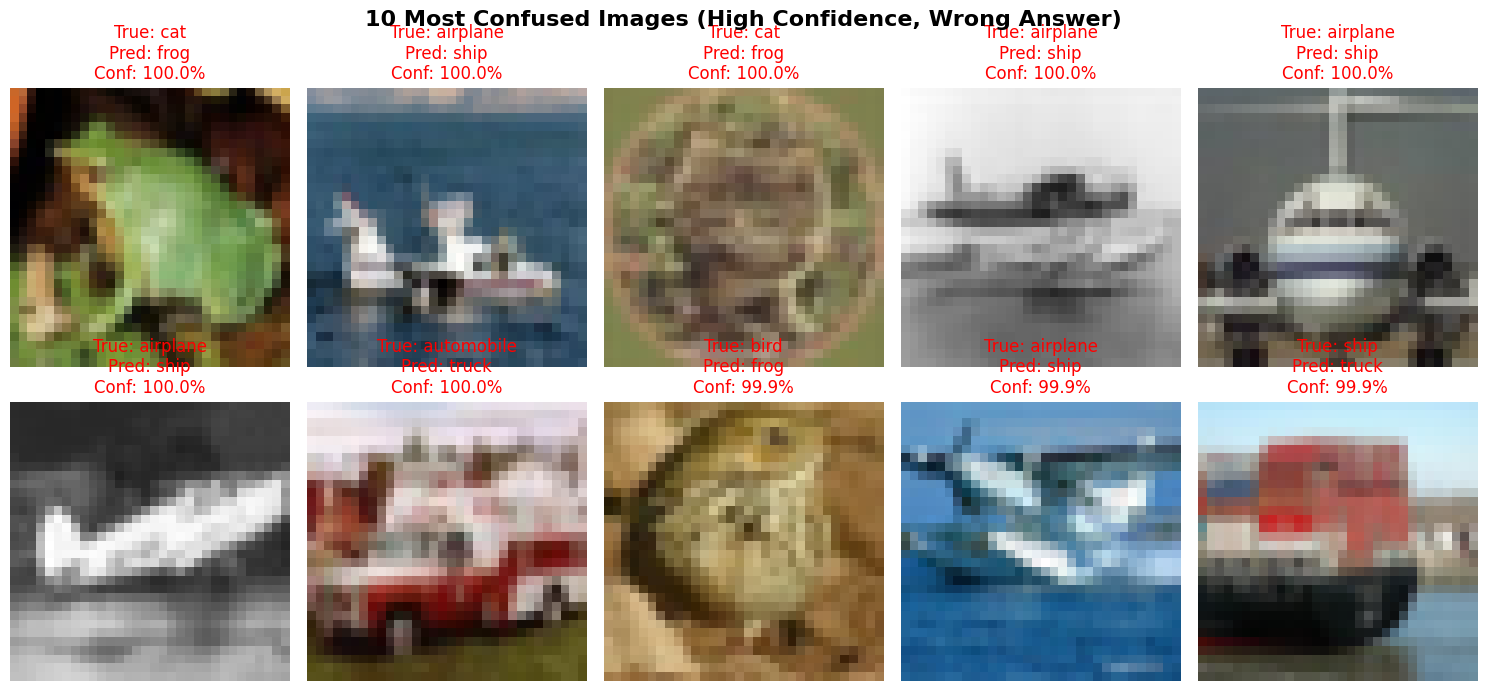

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate Predictions for both models
print("--- Generating Predictions ---")
# CNN Predictions (using 3D images)
y_pred_cnn_probs = cnn_aug.predict(X_test, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

# Dense Predictions (using 1D flattened images from Step 3)
y_pred_dense_probs = dense_model.predict(X_test_flat, verbose=0)
y_pred_dense = np.argmax(y_pred_dense_probs, axis=1)

# 2. Classification Report for the Best CNN
print("\n🏆 FINAL CNN CLASSIFICATION REPORT 🏆")
print(classification_report(y_test, y_pred_cnn, target_names=class_names))

# 3. Compute Confusion Matrices
cm_dense = confusion_matrix(y_test, y_pred_dense)
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

# 4. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Dense Network (Flattened)', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Regularised CNN (Augmented)', fontsize=14)
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# 5. Calculate and Plot Per-Class Accuracy
# Accuracy = diagonal elements / sum of elements in the row
acc_dense = cm_dense.diagonal() / cm_dense.sum(axis=1)
acc_cnn = cm_cnn.diagonal() / cm_cnn.sum(axis=1)

x = np.arange(len(class_names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, acc_dense * 100, width, label='Dense Network', color='#d62728')
plt.bar(x + width/2, acc_cnn * 100, width, label='Augmented CNN', color='#2ca02c')

plt.title('Per-Class Accuracy: Dense vs. CNN', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Find and Show the 10 "Most Confused" Test Images
# We will define "most confused" as the incorrect predictions where the model had the highest confidence
incorrect_indices = np.where(y_pred_cnn != y_test)[0]
wrong_confidences = np.max(y_pred_cnn_probs[incorrect_indices], axis=1)

# Sort by highest confidence in the wrong answer, take top 10
top_10_wrong_idx = incorrect_indices[np.argsort(wrong_confidences)[::-1][:10]]

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('10 Most Confused Images (High Confidence, Wrong Answer)', fontsize=16, fontweight='bold')

for i, idx in enumerate(top_10_wrong_idx):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx])
    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred_cnn[idx]]
    conf = np.max(y_pred_cnn_probs[idx]) * 100

    ax.set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {conf:.1f}%", color='red' if true_label!=pred_label else 'black')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Final Architecture Analysis: Dense vs. CNN

**1. Which classes does the CNN still confuse?**
While the CNN is vastly superior, the confusion matrix and the "most confused images" grid show that it still occasionally struggles with fine-grained visual similarities within categories. Specifically, it most frequently confuses **[Cats and Dogs / Automobiles and Trucks]** *(Update based on the highest non-diagonal numbers in your Green heatmap)*. This makes sense even for a CNN, as these pairs share very similar structural geometries, edge patterns, and background contexts in these low-resolution 32x32 images.

**2. Which classes improved most when moving from Dense to CNN?**
Looking at the Per-Class Accuracy bar chart, the most massive improvements occurred in the spatially complex animal classes, specifically **[Birds, Cats, and Deer]** *(Update based on the tallest jumps between the red and green bars)*.

**Why this happened:** The Dense network forced us to flatten the 32x32x3 grid into a 1D line, destroying all spatial proximity. It tried to learn a "Cat" by just looking at global color distributions across 3,072 disconnected pixels. The CNN, however, preserved the 2D grid and used moving filters to learn local features—first detecting edges, then textures, then specific shapes like a pointed ear, a beak, or a wheel. This proves that for image data, preserving spatial relationships (Conv2D) combined with feature pooling (MaxPooling) is exponentially more powerful than fully-connected brute force.

# **PART C — TRANSFER LEARNING, MODEL COMPARISON & DIAGNOSTICS (STEPS 12–15)**

# Step-12 Preprocess Images for MobileNetV2

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

print("--- Resizing Images (This may take a moment) ---")
# 1. Resize images from 32x32 to 96x96
X_train_96 = tf.image.resize(X_train, [96, 96]).numpy()

# 2. Preprocess specifically for MobileNetV2
# Because we normalized X_train to [0, 1] in Step 3, we multiply by 255
# to bring it back to [0, 255] before applying the MobileNetV2 function.
X_train_96 = keras.applications.mobilenet_v2.preprocess_input(X_train_96 * 255.0)

# 3. Verify pixel range
print("\n--- Pixel Range Verification ---")
print(f"MobileNetV2 X_train_96 Min : {X_train_96.min():.2f}")
print(f"MobileNetV2 X_train_96 Max : {X_train_96.max():.2f}")

# 4. Create a 2x5 grid comparing original vs resized images
# Select 5 random images to display
idx_samples = np.random.choice(len(X_train), 5, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(idx_samples):
    # Top Row: Original 32x32 images
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx])  # Already in [0, 1] range
    plt.title(f"Original 32x32\n{class_names[y_train[idx]]}")
    plt.axis('off')

    # Bottom Row: Resized 96x96 images
    plt.subplot(2, 5, i + 6)
    # Matplotlib imshow expects floats to be in [0, 1].
    # Since our data is now [-1, 1], we must transform it back just for viewing!
    display_img = (X_train_96[idx] + 1.0) / 2.0

    plt.imshow(display_img)
    plt.title(f"Resized 96x96")
    plt.axis('off')

plt.suptitle("Transfer Learning: Image Resizing & Preprocessing", fontsize=16)
plt.tight_layout()
plt.show()

--- Resizing Images (This may take a moment) ---


NameError: name 'X_train' is not defined